In [16]:
# !pip install deepxde

In [17]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

dde.config.set_default_float("float64")


Set the default float type to float64


## Diffusion Equation
$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

In [18]:
def diffusion_pde(x, u):
    du_dt = dde.grad.jacobian(u, x, i=0, j=1)
    du_dx2 = dde.grad.hessian(u, x, i=0, j=0)
    return du_dt - (0.4*du_dx2)

### Interval Defining

In [19]:
time = dde.geometry.TimeDomain(0, 5)
space = dde.geometry.Interval(-5, 5)
geom = dde.geometry.GeometryXTime(space, time)

### Initial and Boundary Condition

In [20]:
bc = dde.icbc.DirichletBC(
    geom, 
    lambda x: 0, 
    lambda _, on_boundary: on_boundary
)
ic = dde.icbc.IC(
    geom,
    lambda x: np.sin(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial
)

In [21]:
exact = lambda x: (np.exp(-0.4 * np.pi**2 * x[:, 1:2])
                    * np.sin(np.pi * x[:, 0:1]))

In [22]:
data = dde.data.TimePDE(
    geom,
    diffusion_pde,
    [bc, ic],
    num_domain=3000,
    num_boundary=400,
    num_initial=400,
    solution=exact,
)

net = dde.nn.FNN([2] + [64] * 4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

In [ ]:
model.compile("adam", lr=1e-3)
model.train(iterations=10000)
model.compile("L-BFGS")
model.train()

8000      [1.04e-03, 7.79e-04, 3.67e-03]    [1.04e-03, 7.79e-04, 3.67e-03]    []  
9000      [7.08e-05, 4.69e-06, 1.70e-05]    [7.08e-05, 4.69e-06, 1.70e-05]    []  
10000     [1.22e-04, 3.49e-05, 1.69e-04]    [1.22e-04, 3.49e-05, 1.69e-04]    []  

Best model at step 9000:
  train loss: 9.26e-05
  test loss: 9.26e-05
  test metric: []

'train' took 114.959231 s

Compiling model...
'compile' took 0.002751 s

Training model...

Step      Train loss                        Test loss                         Test metric
10000     [1.22e-04, 3.49e-05, 1.69e-04]    [1.22e-04, 3.49e-05, 1.69e-04]    []  


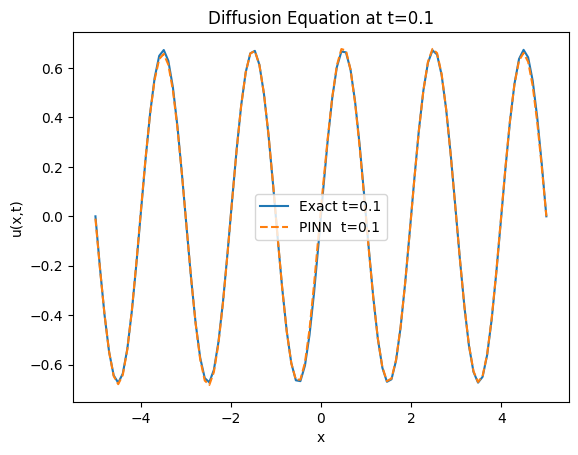

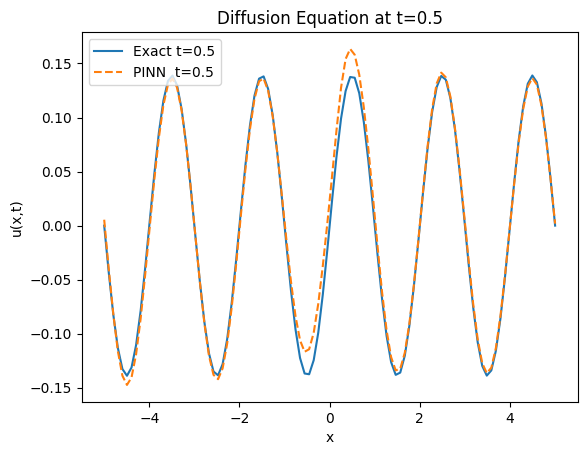

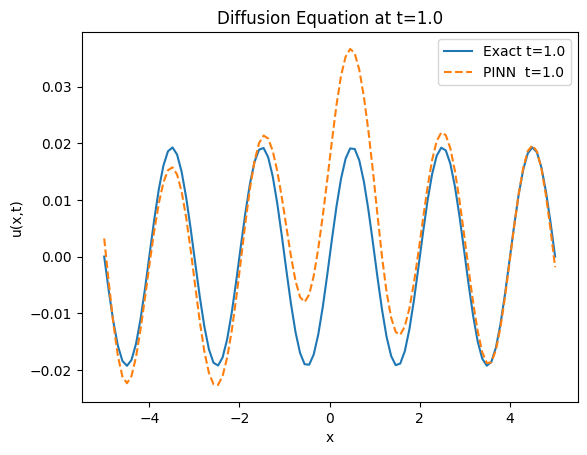

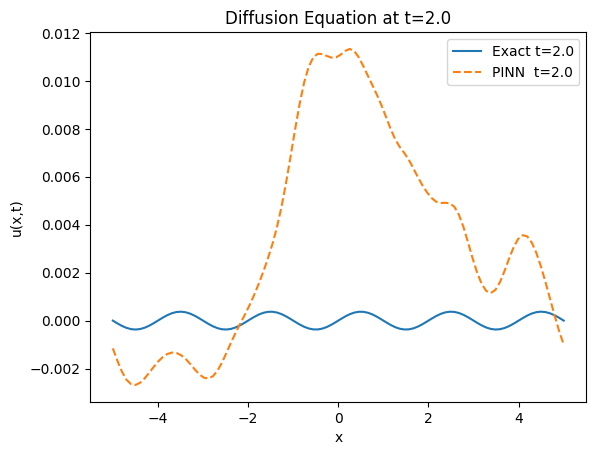

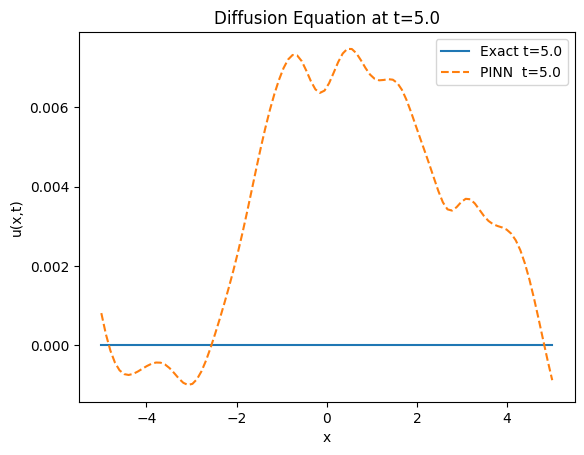

In [ ]:
x = np.linspace(-5, 5, 100)
for t in [0.1, 0.5, 1.0, 2.0, 5.0]:
    xt = np.column_stack([x, np.full_like(x, t)])
    solution = model.predict(xt).flatten()
    u_ex   = (np.exp(-0.4 * np.pi**2 * t)
              * np.sin(np.pi * x))
    plt.plot(x, u_ex,   label=f"Exact t={t}")
    plt.plot(x, solution, "--", label=f"PINN  t={t}")
    plt.title(f"Diffusion Equation at t={t}")
    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.legend()
    plt.show()
